<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/Semana_11_DistanciaClasificadores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Represenación del Espacio de Características

Podemos usar un diagrama de dispersión


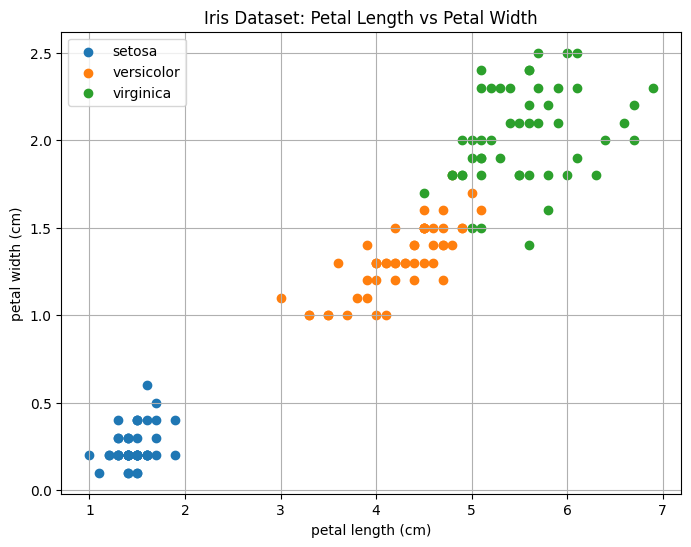

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

# Cargar el dataset Iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Seleccionar las dos características más discriminantes
x1_attr = 'petal length (cm)'
x2_attr = 'petal width (cm)'

# Dibujar scatter plot
plt.figure(figsize=(8, 6))
for species in df['species'].unique():
    subset = df[df['species'] == species]
    plt.scatter(subset[x1_attr], subset[x2_attr], label=species)

plt.xlabel(x1_attr)
plt.ylabel(x2_attr)
plt.title("Iris Dataset: Petal Length vs Petal Width")
plt.legend()
plt.grid(True)
plt.show()

# Diagrama de Dispersión por Cada Atributo

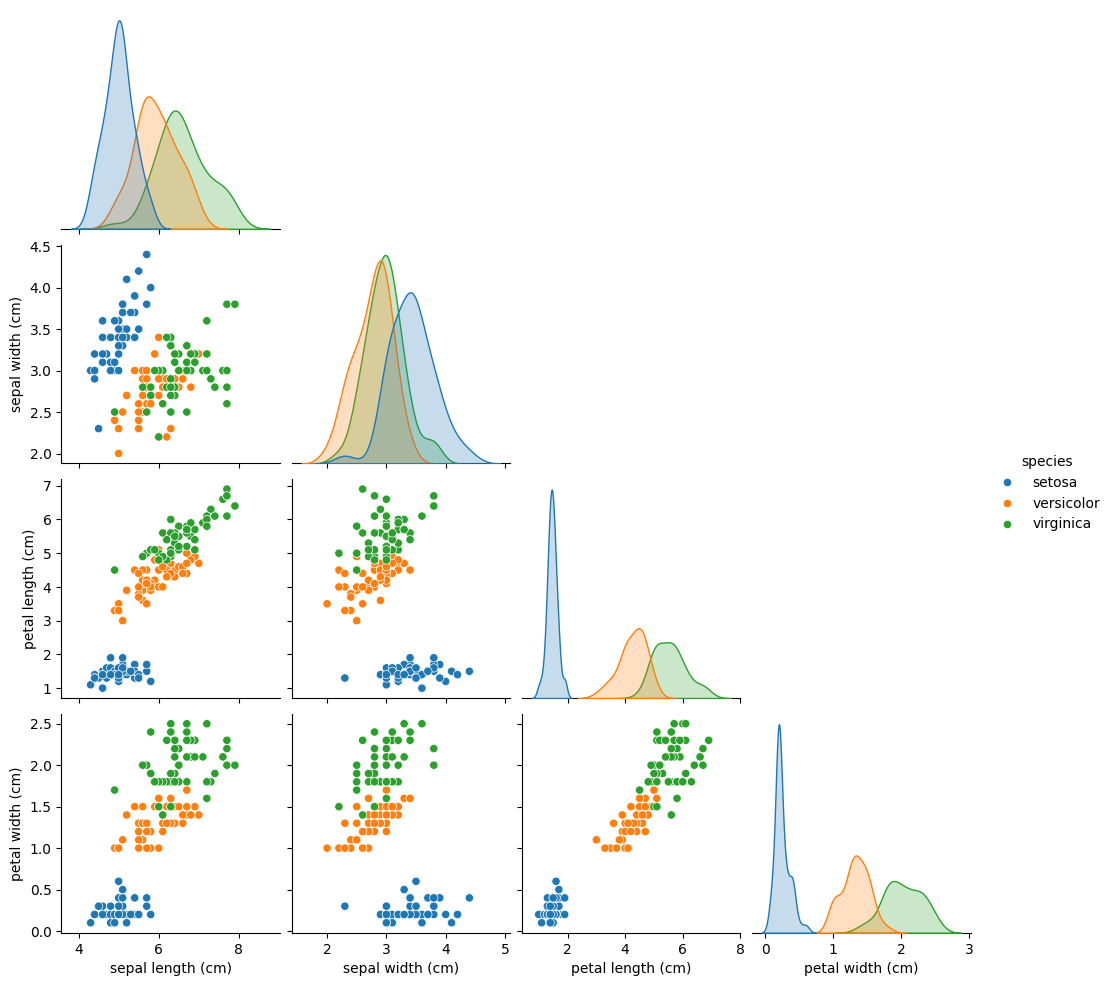

In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris

# Cargar el dataset Iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Agregar columna de nombres de especies (clases)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Dibujar scatter plots para cada par de atributos (sin incluir 'target')
sns.pairplot(df, hue='species', corner=True)



# Ejemplo de Ingreso Manual de un Ejemplo

En este ejemplo se solicita al usuario que introduzca los valores (x1,x2) de un ejemplo aritificial sin etiqueta de clase para ser clasificado

Características disponibles:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Características utilizadas:
1. sepal length (cm)  (ej. entre 4 y 7)
2. petal length (cm)  (ej. entre 1 y 6)

Ingresa un punto (ej. 5.1,1.4): 4,7

 Clase predicha: virginica


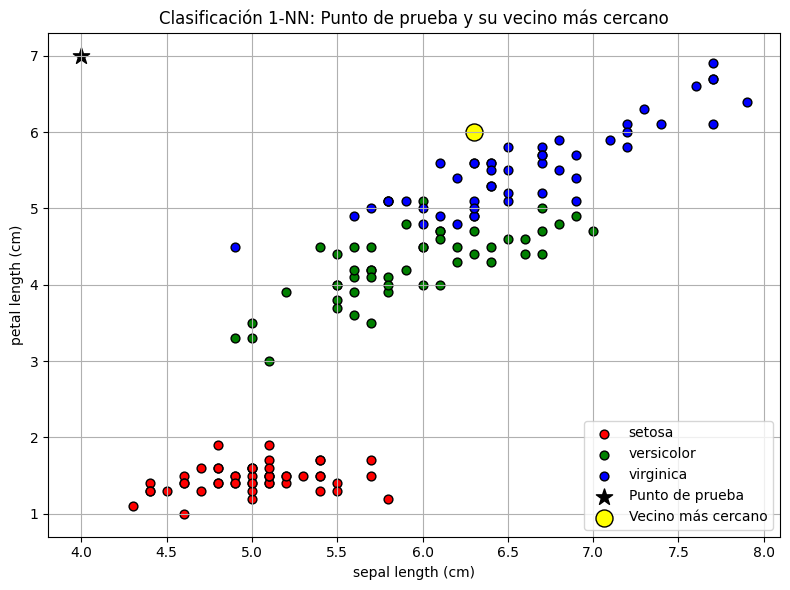

In [ ]:
# Paso 1: Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

# Paso 2: Cargar dataset Iris (solo 2 atributos para visualización 2D)
iris = load_iris()
V = iris.data[:, [0, 2]]  # Se eligen: largo del sépalo y largo del pétalo
y = iris.target
print("Características disponibles:")
print(iris.feature_names)
target_names = iris.target_names
feature_names = [iris.feature_names[i] for i in [0, 2]]

# Paso 3: Entrenar modelo 1-NN
knn = KNeighborsClassifier(n_neighbors=1,weights='uniform', algorithm='auto', p=1, metric='minkowski',)
knn.fit(V, y)

# Paso 4: Ingreso de punto de prueba
print("Características utilizadas:")
print(f"1. {feature_names[0]}  (ej. entre 4 y 7)")
print(f"2. {feature_names[1]}  (ej. entre 1 y 6)")

entrada = input("\nIngresa un punto (ej. 5.1,1.4): ")
test_point = np.array([list(map(float, entrada.strip().split(',')))])

# Paso 5: Predicción y vecino más cercano
pred_class = knn.predict(test_point)[0]
distances = np.linalg.norm(V - test_point, axis=1)
nearest_index = np.argmin(distances)
nearest_point = V[nearest_index]

print(f"\n Clase predicha: {target_names[pred_class]}")

# Paso 6: Visualización
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for i, label in enumerate(np.unique(y)):
    plt.scatter(X[y == label, 0], V[y == label, 1],
                label=target_names[label], c=colors[i], s=40, edgecolor='k')

# Punto de prueba
plt.scatter(test_point[0, 0], test_point[0, 1], c='black', s=150, marker='*', label='Punto de prueba')

# Vecino más cercano
plt.scatter(nearest_point[0], nearest_point[1], c='yellow', s=150, edgecolor='k', label='Vecino más cercano')

# Estética del gráfico
plt.title("Clasificación 1-NN: Punto de prueba y su vecino más cercano")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# K-NN

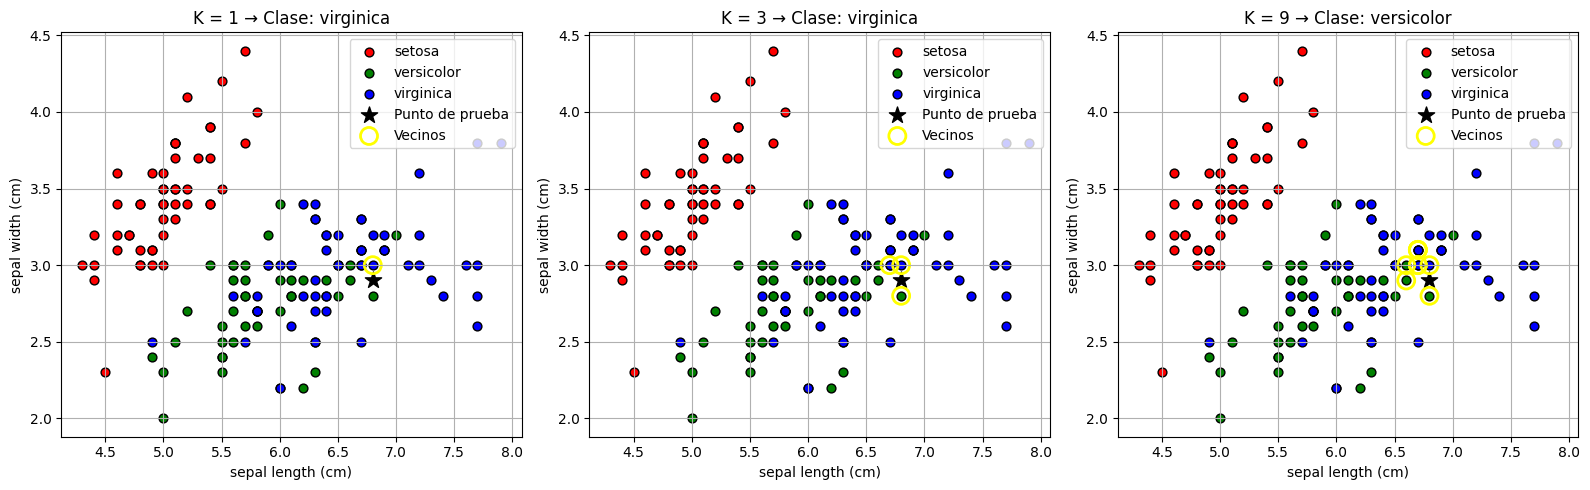

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

# Cargar el dataset Iris (usando solo 2 características para graficar)
iris = load_iris()
X = iris.data[:, [0, 1]]  # sepal length & petal length
y = iris.target
target_names = iris.target_names
feature_names = [iris.feature_names[i] for i in [0, 1]]

# Punto de prueba fijo
test_point = np.array([[6.8, 2.9]])

# Valores de K a comparar
K_values = [1, 3, 9]

# Crear el gráfico
plt.figure(figsize=(16, 5))

colors = ['red', 'green', 'blue']
for i, k in enumerate(K_values, 1):
    # Entrenar el modelo
    knn = KNeighborsClassifier(n_neighbors=k,weights='uniform')
    knn.fit(X, y)

    # Predecir clase
    pred = knn.predict(test_point)[0]
    pred_name = target_names[pred]

    # Obtener vecinos
    neighbor_idx = knn.kneighbors(test_point, return_distance=False)[0]
    neighbors = X[neighbor_idx]

    # Graficar
    plt.subplot(1, 3, i)
    for label in np.unique(y):
        plt.scatter(X[y == label, 0], X[y == label, 1],
                    label=target_names[label], c=colors[label], s=40, edgecolor='k')

    # Punto de prueba
    plt.scatter(test_point[0, 0], test_point[0, 1], c='black', s=150, marker='*', label='Punto de prueba')

    # Vecinos resaltados
    plt.scatter(neighbors[:, 0], neighbors[:, 1], facecolors='none', edgecolors='yellow', s=150, linewidths=2, label='Vecinos')

    # Estética
    plt.title(f"K = {k} → Clase: {pred_name}")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

plt.show()

# Data Splitting/Resampling - Estimación del Error



In [ ]:
#@Hold-out Ejemplo en K-NN
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Datos
X, y = load_breast_cancer(return_X_y=True)

# Split estratificado
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTamaño del conjunto de entrenamiento: {Xtr.shape[0]} muestras ({Xtr.shape[0]/len(X)*100:.1f}%)")
print(f"Tamaño del conjunto de prueba: {Xte.shape[0]} muestras ({Xte.shape[0]/len(X)*100:.1f}%)")


# Modelo
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xtr, ytr)
yp = knn.predict(Xte)

# Métricas
print(classification_report(yte, yp, digits=3))
print("Matriz de confusión:\n", confusion_matrix(yte, yp))



Tamaño del conjunto de entrenamiento: 455 muestras (80.0%)
Tamaño del conjunto de prueba: 114 muestras (20.0%)
              precision    recall  f1-score   support

           0      0.864     0.905     0.884        42
           1      0.943     0.917     0.930        72

    accuracy                          0.912       114
   macro avg      0.903     0.911     0.907       114
weighted avg      0.914     0.912     0.913       114

Matriz de confusión:
 [[38  4]
 [ 6 66]]


## K-Fold Cross-Validation (No estratificado)


🔹 MÉTODO 2: K-FOLD CROSS-VALIDATION

📊 Resultados de 5-Fold Cross-Validation:
   Fold 1: 0.9561
   Fold 2: 0.9649
   Fold 3: 0.8947
   Fold 4: 0.9561
   Fold 5: 0.9115

✅ Accuracy promedio: 0.9367 (± 0.0281)


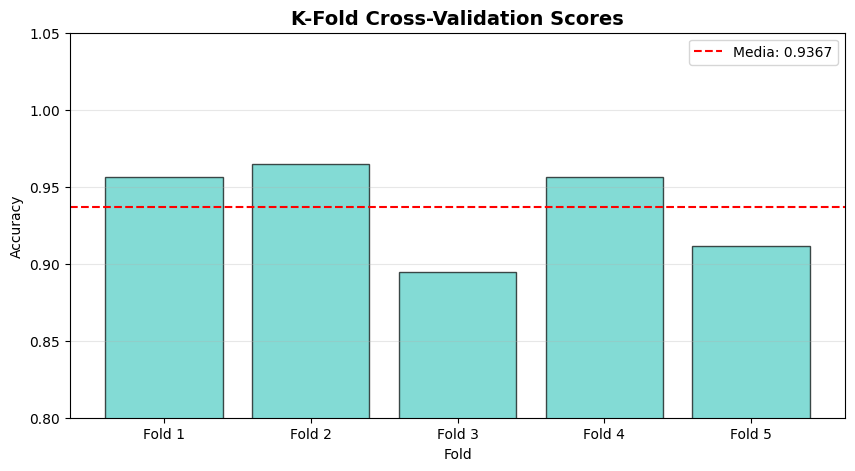


🔍 Distribución de clases en cada fold:
   Fold 1 - Train: [169 286], Test: [43 71]
   Fold 2 - Train: [175 280], Test: [37 77]
   Fold 3 - Train: [169 286], Test: [43 71]
   Fold 4 - Train: [169 286], Test: [43 71]
   Fold 5 - Train: [166 290], Test: [46 67]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    cross_validate
)
print("\n" + "="*60)
print("🔹 MÉTODO 2: K-FOLD CROSS-VALIDATION")
print("="*60)

# Configurar K-Fold
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)



# Realizar K-Fold Cross-Validation
knn_cv = KNeighborsClassifier(n_neighbors=5)
cv_scores = cross_val_score(knn_cv, X, y, cv=kf, scoring='accuracy')



print(f"\n📊 Resultados de {k_folds}-Fold Cross-Validation:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score:.4f}")

print(f"\n✅ Accuracy promedio: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

# Visualizar scores por fold
plt.figure(figsize=(10, 5))
folds = [f'Fold {i}' for i in range(1, k_folds + 1)]
plt.bar(folds, cv_scores, color='#4ECDC4', alpha=0.7, edgecolor='black')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--',
            label=f'Media: {cv_scores.mean():.4f}')
plt.title('K-Fold Cross-Validation Scores', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Fold')
plt.ylim([0.8, 1.05])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Verificar distribución de clases en cada fold
print("\n🔍 Distribución de clases en cada fold:")
for i, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
    train_dist = np.bincount(y[train_idx])
    test_dist = np.bincount(y[test_idx])
    print(f"   Fold {i} - Train: {train_dist}, Test: {test_dist}")


# Stratified K-Fold Cross-Validation

Mantiene la proporción de clases en cada fold

In [ ]:
print("\n" + "="*60)
print("🔹 MÉTODO: STRATIFIED K-FOLD CROSS-VALIDATION")
print("="*60)

# Configurar Stratified K-Fold
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Realizar Stratified K-Fold CV
stratified_scores = cross_val_score(knn_cv, X, y, cv=skf, scoring='accuracy')

print(f"\n📊 Resultados de Stratified {k_folds}-Fold Cross-Validation:")
for i, score in enumerate(stratified_scores, 1):
    print(f"   Fold {i}: {score:.4f}")

print(f"\n✅ Accuracy promedio: {stratified_scores.mean():.4f} (± {stratified_scores.std():.4f})")

# Verificar distribución de clases en cada fold
print("\n🔍 Distribución de clases en cada fold:")
for i, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    train_dist = np.bincount(y[train_idx])
    test_dist = np.bincount(y[test_idx])
    print(f"   Fold {i} - Train: {train_dist}, Test: {test_dist}")


🔹 MÉTODO: STRATIFIED K-FOLD CROSS-VALIDATION

📊 Resultados de Stratified 5-Fold Cross-Validation:
   Fold 1: 0.9298
   Fold 2: 0.9035
   Fold 3: 0.9298
   Fold 4: 0.9561
   Fold 5: 0.9558

✅ Accuracy promedio: 0.9350 (± 0.0196)

🔍 Distribución de clases en cada fold:
   Fold 1 - Train: [169 286], Test: [43 71]
   Fold 2 - Train: [169 286], Test: [43 71]
   Fold 3 - Train: [170 285], Test: [42 72]
   Fold 4 - Train: [170 285], Test: [42 72]
   Fold 5 - Train: [170 286], Test: [42 71]


#  Leave-One-Out Cross-Validation (LOOCV)

Usa todas las muestras menos una para entrenar (caso extremo de K-Fold).


In [ ]:
print("\n" + "="*60)
print("🔹 MÉTODO: LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV)")
print("="*60)

# Configurar LOOCV (puede ser lento con datasets grandes)
loo = LeaveOneOut()

# Para demostración, usar subset más pequeño
X_subset = X[:50]  # Primeras 50 muestras
y_subset = y[:50]
X_subset_scaled = scaler.fit_transform(X_subset)

print(f"\n⚠️  Usando subset de {len(X_subset)} muestras (LOOCV es computacionalmente costoso)")

# Realizar LOOCV
loocv_scores = cross_val_score(knn_cv, X_subset_scaled, y_subset,
                                cv=loo, scoring='accuracy')

print(f"\n✅ Accuracy promedio: {loocv_scores.mean():.4f} (± {loocv_scores.std():.4f})")
print(f"Número de iteraciones: {len(loocv_scores)}")


🔹 MÉTODO: LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV)

⚠️  Usando subset de 50 muestras (LOOCV es computacionalmente costoso)

✅ Accuracy promedio: 0.9600 (± 0.1960)
Número de iteraciones: 50


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/sample_data/Paw50.csv')

print(df.columns)


XPaw50 = df.drop('Clase', axis=1)  # Todas menos el target
yPaw50 = df['Clase']

print("\n" + "="*60)
print("🔹 MÉTODO: STRATIFIED K-FOLD CROSS-VALIDATION")
print("="*60)

# Configurar Stratified K-Fold
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Realizar Stratified K-Fold CV
stratified_scores = cross_val_score(knn_cv, XPaw50, y, cv=skf, scoring='accuracy')

print(f"\n📊 Resultados de Stratified {k_folds}-Fold Cross-Validation:")
for i, score in enumerate(stratified_scores, 1):
    print(f"   Fold {i}: {score:.4f}")

print(f"\n✅ Accuracy promedio: {stratified_scores.mean():.4f} (± {stratified_scores.std():.4f})")

# Verificar distribución de clases en cada fold
print("\n🔍 Distribución de clases en cada fold:")
for i, (train_idx, test_idx) in enumerate(skf.split(XPaw50, yPaw50), 1):
    train_dist = np.bincount(yPaw50[train_idx])
    test_dist = np.bincount(yPaw50[test_idx])
    print(f"   Fold {i} - Train: {train_dist}, Test: {test_dist}")

Index(['Atributo1', 'Atributo2', 'Clase'], dtype='object')

🔹 MÉTODO: STRATIFIED K-FOLD CROSS-VALIDATION

📊 Resultados de Stratified 5-Fold Cross-Validation:
   Fold 1: 0.9167
   Fold 2: 0.8833
   Fold 3: 0.8583
   Fold 4: 0.8667
   Fold 5: 0.9083

✅ Accuracy promedio: 0.8867 (± 0.0227)

🔍 Distribución de clases en cada fold:
   Fold 1 - Train: [ 80 400], Test: [ 20 100]
   Fold 2 - Train: [ 80 400], Test: [ 20 100]
   Fold 3 - Train: [ 80 400], Test: [ 20 100]
   Fold 4 - Train: [ 80 400], Test: [ 20 100]
   Fold 5 - Train: [ 80 400], Test: [ 20 100]


Curvas de Error

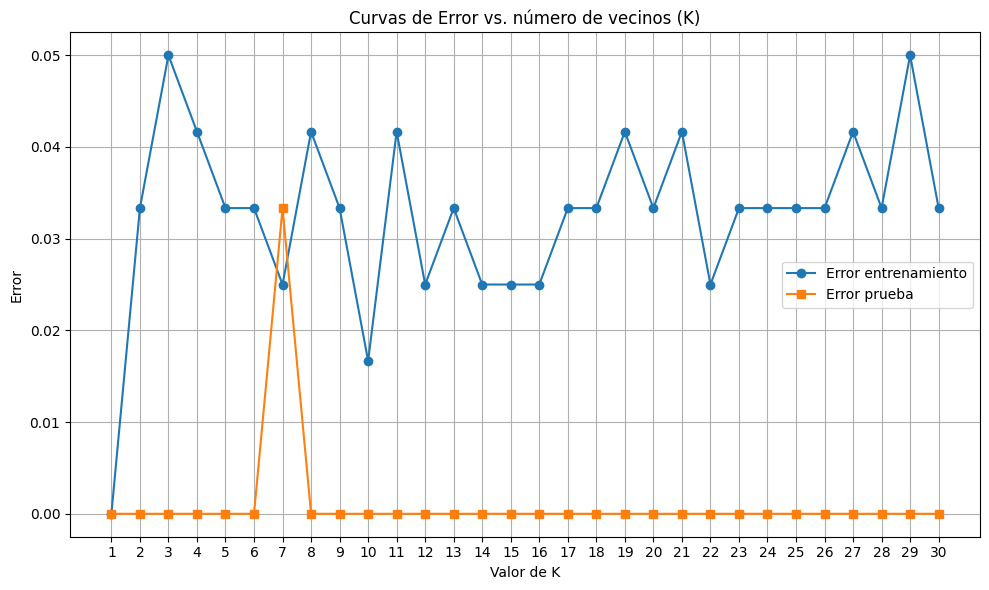

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Cargar datos (usamos las 4 características)
iris = load_iris()
X = iris.data
y = iris.target

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Probar valores de K
k_range = range(1, 31)
train_accuracies = []
test_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_acc = 1-accuracy_score(y_train, knn.predict(X_train))
    test_acc = 1-accuracy_score(y_test, knn.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_accuracies, label='Error entrenamiento', marker='o')
plt.plot(k_range, test_accuracies, label='Error prueba', marker='s')
plt.xlabel("Valor de K")
plt.ylabel("Error")
plt.title("Curvas de Error vs. número de vecinos (K)")
plt.legend()
plt.grid(True)
plt.xticks(k_range)
plt.tight_layout()
plt.show()


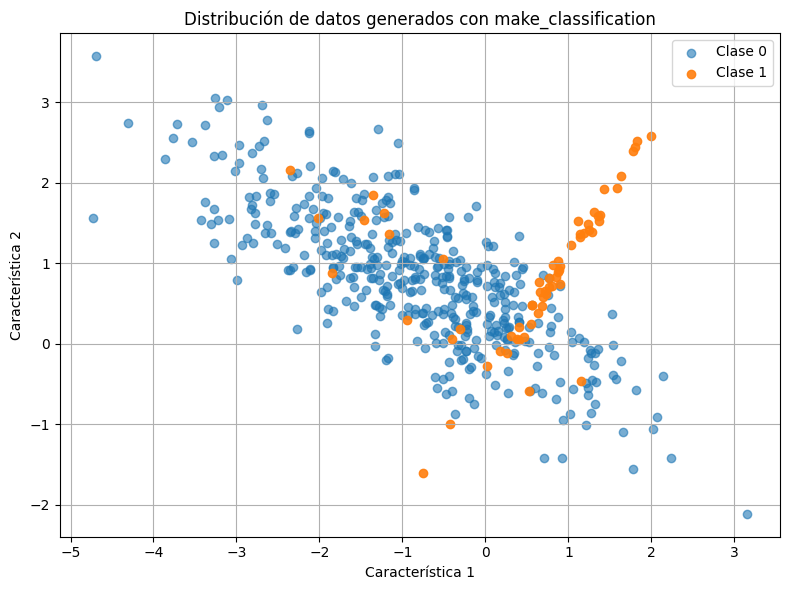

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Crear datos con solapamiento y desbalance
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],         # 90% clase 0, 10% clase 1
    class_sep=0.8,              # Clase_sep bajo → solapamiento
    flip_y=0.05,                # Ruido adicional
    random_state=42
)

# Crear el scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Clase 0", alpha=0.6)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Clase 1", alpha=0.9)
plt.title("Distribución de datos generados con make_classification")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


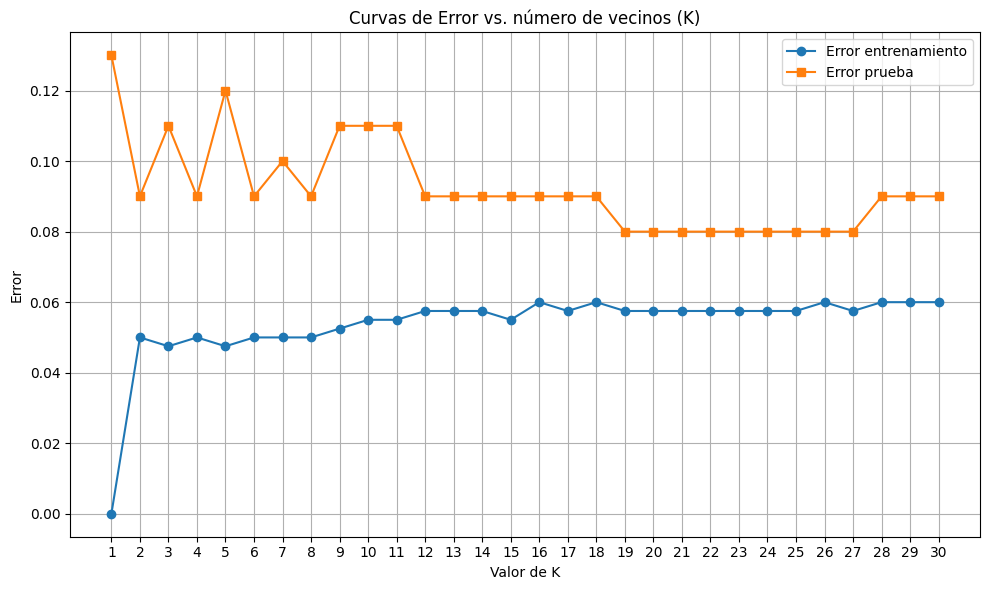

In [ ]:
# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)



# Probar valores de K
k_range = range(1, 31)
train_accuracies = []
test_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_acc = 1-accuracy_score(y_train, knn.predict(X_train))
    test_acc = 1-accuracy_score(y_test, knn.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_accuracies, label='Error entrenamiento', marker='o')
plt.plot(k_range, test_accuracies, label='Error prueba', marker='s')
plt.xlabel("Valor de K")
plt.ylabel("Error")
plt.title("Curvas de Error vs. número de vecinos (K)")
plt.legend()
plt.grid(True)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

Curvas de error en la clase 0, la clase predominante

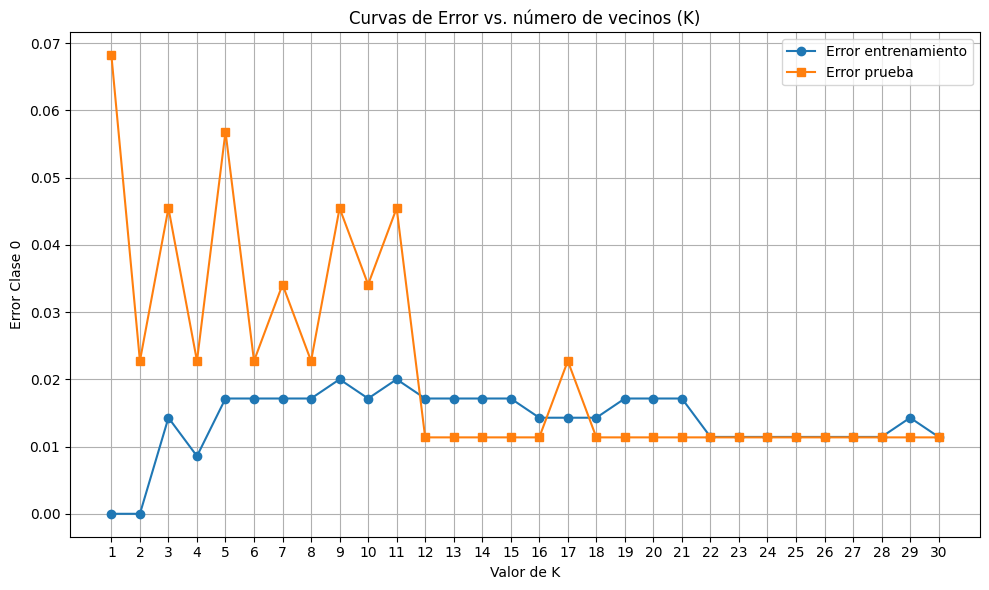

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

#
# Probar valores de K
k_range = range(1, 31)
train_accuracies = []
test_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_acc = 1-recall_score(y_train, knn.predict(X_train),pos_label =0)
    test_acc = 1-recall_score(y_test, knn.predict(X_test),pos_label=0)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_accuracies, label='Error entrenamiento', marker='o')
plt.plot(k_range, test_accuracies, label='Error prueba', marker='s')
plt.xlabel("Valor de K")
plt.ylabel("Error Clase 0")
plt.title("Curvas de Error vs. número de vecinos (K)")
plt.legend()
plt.grid(True)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

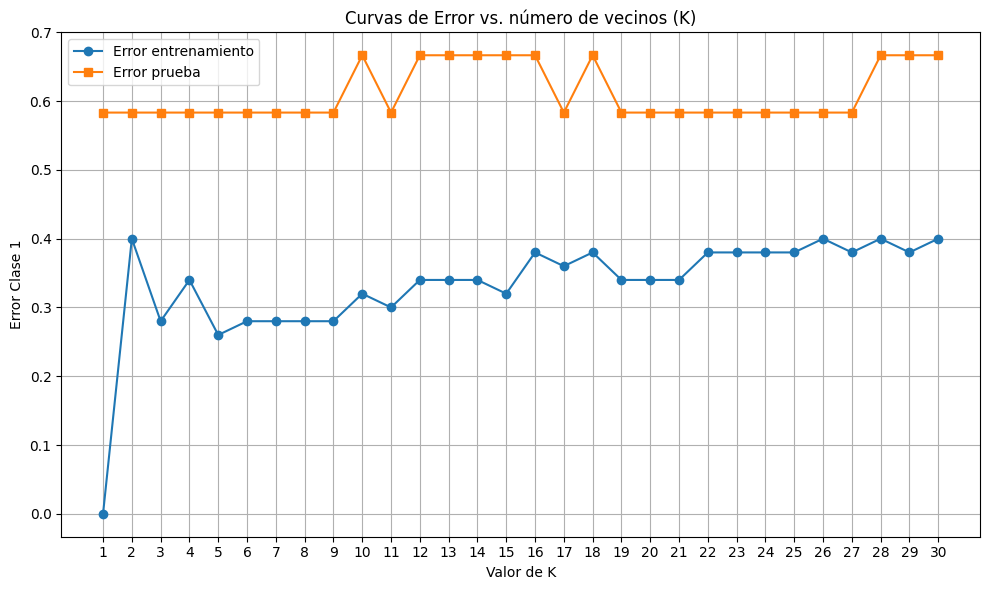

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

#
# Probar valores de K
k_range = range(1, 31)
train_accuracies = []
test_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_acc = 1-recall_score(y_train, knn.predict(X_train),pos_label =1)
    test_acc = 1-recall_score(y_test, knn.predict(X_test),pos_label=1)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_accuracies, label='Error entrenamiento', marker='o')
plt.plot(k_range, test_accuracies, label='Error prueba', marker='s')
plt.xlabel("Valor de K")
plt.ylabel("Error Clase 1")
plt.title("Curvas de Error vs. número de vecinos (K)")
plt.legend()
plt.grid(True)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

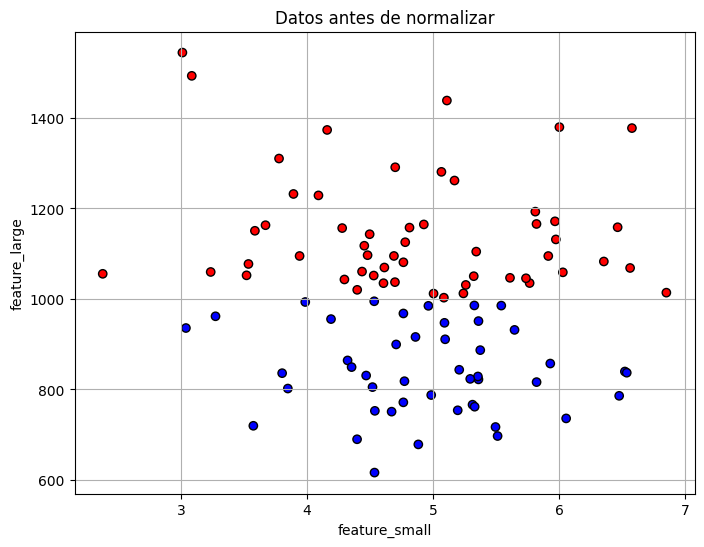

Exactitud SIN normalizar: 0.97
Exactitud CON normalización: 1.00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Crear un conjunto de datos artificial
np.random.seed(42)
n_samples = 100
x1 = np.random.normal(5, 1, size=n_samples)       # variable 1 en escala pequeña
x2 = np.random.normal(1000, 200, size=n_samples)  # variable 2 en escala grande
y = (x1 + x2 > 1005).astype(int)                  # regla de clase artificial

# Combinar en DataFrame
X = np.vstack((x1, x2)).T
df = pd.DataFrame(X, columns=['feature_small', 'feature_large'])
df['class'] = y

# Visualizar los datos
plt.figure(figsize=(8, 6))
plt.scatter(df['feature_small'], df['feature_large'], c=df['class'], cmap='bwr', edgecolor='k')
plt.xlabel('feature_small')
plt.ylabel('feature_large')
plt.title('Datos antes de normalizar')
plt.grid(True)
plt.show()

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# K-NN sin normalizar
knn_raw = KNeighborsClassifier(n_neighbors=3)
knn_raw.fit(X_train, y_train)
y_pred_raw = knn_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)
print(f"Exactitud SIN normalizar: {acc_raw:.2f}")

# Normalizar
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

# K-NN con datos normalizados
knn_scaled = KNeighborsClassifier(n_neighbors=3)
knn_scaled.fit(X_train_norm, y_train)
y_pred_scaled = knn_scaled.predict(X_test_norm)
acc_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"Exactitud CON normalización: {acc_scaled:.2f}")
